# Social Media Content Optimization Model

This model identifies which content decisions -- platform, post type, media format, topic, sentiment, timing, and call to action -- actually drive donation conversions for Luz de Vida, as opposed to simply generating engagement (likes, shares, comments). The founders manage all social media personally without a marketing team and need data-backed answers to three operational questions: what to post, where to post it, and when to post it.

The pipeline produces a **per-post conversion probability** that administrators can use to:
- Evaluate past posts by their actual donation-driving value, not just their engagement rate
- Identify which controllable content decisions most reliably lead to donations versus those that inflate likes without converting
- Guide future posting decisions with specific recommendations on platform, format, topic, and timing

This notebook covers **Step 1 (Business Problem Framing)** and **Step 2 (Data Acquisition and Preparation)**. Later sections will handle exploration, modeling, evaluation, feature selection, and deployment.

## Step 1 -- Business Problem Framing

### 1.1 Business Question

**Which content decisions -- what to post, on which platform, and at what time -- actually lead to donation conversions, and which only generate engagement?**

Luz de Vida relies on social media as its primary channel for reaching potential donors but lacks the marketing expertise to post strategically. The founders are posting sporadically across platforms without clear guidance on what works. Engagement metrics (likes, shares, comments) are visible but misleading: a post can generate strong engagement and zero donations, while a quiet post with few likes produces multiple referral conversions. This pipeline separates true conversion signal from engagement noise so that the founders can make confident, data-backed decisions about every post they publish.

### 1.2 Prediction vs. Explanation

This pipeline produces two distinct models:

- **Predictive model**: Optimized for out-of-sample accuracy. The goal is a reliable probability estimate -- given the planned content characteristics of a post, what is the probability it will convert? Ensemble methods (gradient boosting) are appropriate here because they capture non-linear interactions among content features and generally produce the best discrimination on tabular data.
- **Explanatory model**: A carefully specified logistic regression where coefficient interpretability matters. This model answers the question: *"Which content decisions most strongly drive conversion?"* Odds ratios will be interpretable in operational terms -- for example, whether including a resident story multiplies conversion odds, or whether a specific platform has a systematic advantage. This gives the founders actionable guidance they can apply before publishing every post.

### 1.3 Target Variable

The target is derived from `donation_referrals` in the `social_media_posts` table, which records how many donation transactions were directly attributed to each post:

| Condition | Label | Encoding |
|-----------|-------|----------|
| donation_referrals > 0 | Converted | 1 |
| donation_referrals == 0 | Not Converted | 0 |

**Why this variable?** `engagement_rate` was considered but rejected because it conflates likes, shares, and comments with actual donor action -- the entire purpose of this model is to separate those signals. `estimated_donation_value_php` was also considered as a regression target but rejected in favor of binary classification: the immediate operational question is whether a post converts at all, not the exact donation value generated. Binary conversion probability is also more interpretable for non-technical founders making day-to-day posting decisions.

The `donations` table provides additional context on each referral donation: `is_recurring`, `donation_type`, and `amount`. These are aggregated per post and included in the dataset for exploratory analysis, but excluded from the predictive feature set because they are outcomes that occur after the post is published.

### 1.4 Success Metrics

- **Primary metric**: AUC-ROC -- appropriate for imbalanced binary classification and for producing a ranked probability score rather than a fixed label
- **Secondary metric**: Recall on the converted class -- missing a content strategy that actually drives donations is more costly than over-recommending a format that does not convert
- **Baseline**: A naive classifier that labels every post as "converted" (the actual majority class at 64%). The model must meaningfully outperform this baseline on both metrics and must demonstrate genuine predictive lift rather than simply reflecting the base rate.

### 1.5 Dataset Feasibility Note

The dataset contains approximately 812 posts spanning multiple platforms and over two years. This is a stronger sample than the other two pipelines in this project, but several constraints still apply:

1. **Class distribution is favorable** -- approximately 64% of posts in the dataset generated at least one donation referral, making the converted class the majority. The minority class (not converted) may still benefit from class weighting at modeling time, but severe imbalance is not a concern here.
2. **Cross-validation is required** -- stratified 5-fold CV ensures that performance estimates account for the class imbalance and are not the result of a favorable train/test split.
3. **Feature expansion through encoding** -- the raw feature matrix includes several categorical columns (platform, post_type, media_type, content_topic, sentiment_tone) that expand through one-hot encoding. VIF pruning and Gini importance selection will reduce dimensionality before final modeling.
4. **Leakage risk is high** -- engagement metrics (likes, shares, reach, engagement_rate, profile_visits) are all measured after the post is published and must be completely excluded from the predictive feature set. Only decisions the founder makes before publishing are valid inputs to the model.

## Step 2 -- Data Acquisition and Preparation

Data is drawn from two tables. The social_media_posts table is the primary source and contains both the content decisions made before posting and the engagement outcomes measured afterward. The donations table provides referral-level donation quality metrics that enrich the per-post analysis.

Tables loaded:
- **social_media_posts.csv** -- Core table; one row per post; source of the target variable, all content features, and post-outcome engagement metrics
- **donations.csv** -- Donation transaction table; joined via referral_post_id to surface is_recurring, donation_type, and amount for posts that generated referrals

**Not loaded**: residents.csv, health_wellbeing_records.csv, education_records.csv, home_visitations.csv, incident_reports.csv, intervention_plans.csv, process_recordings.csv, safehouses.csv, supporters.csv, or any other operational table. Social media content decisions are entirely self-contained in these two tables.

### 2.1 Configuration

Column lists are defined upfront so that every drop decision is explicit and auditable. Two categories of columns are excluded from the predictive feature set:

- **Post-outcome engagement columns**: measured after publishing; the founder cannot know these before the post goes live
- **Admin and redundant text columns**: identifiers with no signal, raw text fields already captured by derived numeric features, and a pre-aggregated donation outcome that directly encodes the target

In [1]:
# -- Configuration ------------------------------------------------------------
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("dataset")

# Post-outcome engagement columns -- measured after publishing, not known before posting
# Excluded from the predictive feature set to prevent data leakage
ENGAGEMENT_OUTCOME_COLS = [
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "video_views",
    "watch_time_seconds",
    "avg_view_duration_seconds",
    "forwards",
    "engagement_rate",
    "profile_visits",
]

# Admin identifiers and redundant text columns -- no predictive signal
ADMIN_DROP_COLS = [
    "post_id",                       # admin identifier; used for join then discarded
    "platform_post_id",              # platform-specific identifier string
    "post_url",                      # URL string; no signal
    "caption",                       # raw text; caption_length already extracted
    "hashtags",                      # raw hashtag string; num_hashtags already extracted
    "created_at",                    # datetime; day_of_week and post_hour already extracted
    "estimated_donation_value_php",  # pre-aggregated post-level donation outcome; correlated with target
]

# Columns from the donations join retained for EDA analysis only
# These describe outcomes that follow a conversion -- they cannot be known before posting
EDA_ONLY_COLS = ["referral_is_recurring", "referral_top_donation_type", "referral_total_amount"]

print("Configuration loaded.")
print(f"  Engagement outcome columns to remove: {len(ENGAGEMENT_OUTCOME_COLS)}")
print(f"  Admin/text columns to remove:         {len(ADMIN_DROP_COLS)}")

Configuration loaded.
  Engagement outcome columns to remove: 13
  Admin/text columns to remove:         7


### 2.2 Load Tables

In [2]:
# -- Load tables --------------------------------------------------------------
posts     = pd.read_csv(DATA_DIR / "social_media_posts.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")

print(f"social_media_posts:  {posts.shape}")
print(f"donations:           {donations.shape}")
print(f"  referral donations (referral_post_id not null): {donations['referral_post_id'].notna().sum()}")

social_media_posts:  (812, 39)
donations:           (420, 13)
  referral donations (referral_post_id not null): 77


### 2.3 Donations Join

One post can generate multiple referral donations, so the donations table must be aggregated to the post level before joining. Three fields are surfaced per project requirements:

- **referral_is_recurring**: True if any donation linked to this post was a recurring gift -- signals whether the post attracted sustained donors, not just one-time contributors
- **referral_top_donation_type**: The most common donation type among referrals (Monetary, InKind, or Time) -- indicates what kind of giving the post motivated
- **referral_total_amount**: Sum of monetary `amount` across all referral donations -- note that InKind and Time donations have a null `amount` and contribute 0 to this total; monetary value only

Posts with no referral donations receive False, "None", and 0.0 respectively. These three columns are EDA-only and will not be included in the predictive feature set.

In [3]:
# -- Aggregate donations per referral post ------------------------------------
referral_donations = donations[donations["referral_post_id"].notna()].copy()
referral_donations["referral_post_id"] = referral_donations["referral_post_id"].astype(int)

referral_quality = (
    referral_donations
    .groupby("referral_post_id")
    .agg(
        referral_is_recurring=("is_recurring", "any"),
        referral_top_donation_type=("donation_type", lambda x: x.value_counts().index[0]),
        referral_total_amount=("amount", "sum"),
    )
    .reset_index()
    .rename(columns={"referral_post_id": "post_id"})
)

posts = posts.merge(referral_quality, on="post_id", how="left")

# Fill nulls for posts with no referral donations
posts["referral_is_recurring"]       = posts["referral_is_recurring"].eq(True)
posts["referral_top_donation_type"]  = posts["referral_top_donation_type"].fillna("None")
posts["referral_total_amount"]       = posts["referral_total_amount"].fillna(0.0)

print(f"Posts after join:              {posts.shape}")
print(f"Posts with any referral:       {(posts['donation_referrals'] > 0).sum()}")
print(f"Posts with recurring referral: {posts['referral_is_recurring'].sum()}")

Posts after join:              (812, 42)
Posts with any referral:       522
Posts with recurring referral: 30


### 2.4 Target Variable Construction

The binary target `converted` is derived from `donation_referrals`: any post with at least one referral donation is labeled 1 (Converted), all others are labeled 0 (Not Converted). After constructing the target, `donation_referrals` is dropped immediately so it cannot leak into features.

In [4]:
# -- Construct binary target --------------------------------------------------
posts["converted"] = (posts["donation_referrals"] > 0).astype(int)

label_counts = posts["converted"].value_counts().rename({0: "Not Converted (0)", 1: "Converted (1)"})
print("Class distribution:")
print(label_counts)
print(f"\nConversion rate: {posts['converted'].mean():.1%}")
print(f"Imbalance ratio: {label_counts.max()} majority : {label_counts.min()} minority")
print("\nNote: converted is the majority class. Class weighting may still be applied at modeling time.")

# Drop source column -- now encoded in 'converted'
posts.drop(columns=["donation_referrals"], inplace=True)

Class distribution:
converted
Converted (1)        522
Not Converted (0)    290
Name: count, dtype: int64

Conversion rate: 64.3%
Imbalance ratio: 522 majority : 290 minority

Note: converted is the majority class. Class weighting may still be applied at modeling time.


### 2.5 Leakage Column Removal

The most critical step in this pipeline is separating what the founder decides *before* posting from what is measured *after* posting. Two categories of columns are removed:

1. **Post-outcome engagement metrics** (13 columns): `impressions`, `reach`, `likes`, `comments`, `shares`, `saves`, `click_throughs`, `video_views`, `watch_time_seconds`, `avg_view_duration_seconds`, `forwards`, `engagement_rate`, `profile_visits` -- all measured after the post is published. Using these as features would give the model knowledge it could never have at prediction time.

2. **Admin identifiers and redundant fields** (7 columns): `post_id`, `platform_post_id`, `post_url`, `caption`, `hashtags`, `created_at`, `estimated_donation_value_php` -- identifiers with no predictive signal, raw text fields already captured by `caption_length` and `num_hashtags`, a decomposed datetime already captured by `day_of_week` and `post_hour`, and a pre-aggregated donation outcome that directly encodes the target.

After removing leakage columns, three structural null patterns are addressed:
- `boost_budget_php` is null when `is_boosted == False`; fill with 0
- `call_to_action_type` is null when `has_call_to_action == False`; fill with "None"
- `subscriber_count_at_post` is null for non-YouTube platforms; fill with 0

Finally, `campaign_name` has many distinct string values that would require high-cardinality encoding. It is collapsed into a binary `in_campaign` flag (1 if the post was part of a named campaign, 0 otherwise).

In [5]:
# -- Remove leakage columns ---------------------------------------------------
all_drop = ENGAGEMENT_OUTCOME_COLS + ADMIN_DROP_COLS
posts.drop(columns=[c for c in all_drop if c in posts.columns], inplace=True)

# -- Structural null imputation -----------------------------------------------
# boost_budget_php is null when is_boosted == False; a non-boosted post has zero spend
posts["boost_budget_php"] = posts["boost_budget_php"].fillna(0.0)

# call_to_action_type is null when has_call_to_action == False; label as "None"
posts["call_to_action_type"] = posts["call_to_action_type"].fillna("None")

# subscriber_count_at_post is null for non-YouTube platforms; non-applicable platforms get 0
posts["subscriber_count_at_post"] = posts["subscriber_count_at_post"].fillna(0.0)

# -- Collapse campaign_name to binary flag ------------------------------------
# campaign_name has too many distinct values for direct encoding;
# binary presence flag preserves the campaign vs. organic distinction
posts["in_campaign"] = posts["campaign_name"].notna().astype(int)
posts.drop(columns=["campaign_name"], inplace=True)

print(f"Leakage columns removed. Remaining columns: {posts.shape[1]}")

Leakage columns removed. Remaining columns: 22


### 2.6 Final Dataset Summary

The prepared dataset contains one row per social media post. The predictive feature set consists of pre-post content decisions the founder controls before publishing. The EDA-only columns (referral_is_recurring, referral_top_donation_type, referral_total_amount) are retained here for the exploration section but will be excluded when constructing the feature matrix for modeling.

In [6]:
# -- Final dataset summary ----------------------------------------------------
print(f"Dataset shape: {posts.shape}")
print()

print("Column inventory (by type):")
print(posts.dtypes.to_string())
print()

print("Missing values:")
missing = posts.isnull().sum()
missing = missing[missing > 0]
print(missing.to_string() if len(missing) > 0 else "  None")
print()

print("Target distribution:")
print(posts["converted"].value_counts().rename({0: "Not Converted (0)", 1: "Converted (1)"}))
print()

print("EDA-only columns (retained for exploration, excluded from predictive feature set):")
print(EDA_ONLY_COLS)
print()

print("Sample (first 3 rows):")
print(posts.head(3).to_string())

Dataset shape: (812, 22)

Column inventory (by type):
platform                       object
day_of_week                    object
post_hour                       int64
post_type                      object
media_type                     object
num_hashtags                    int64
mentions_count                  int64
has_call_to_action               bool
call_to_action_type            object
content_topic                  object
sentiment_tone                 object
caption_length                  int64
features_resident_story          bool
is_boosted                       bool
boost_budget_php              float64
follower_count_at_post          int64
subscriber_count_at_post      float64
referral_is_recurring            bool
referral_top_donation_type     object
referral_total_amount         float64
converted                       int64
in_campaign                     int64

Missing values:
  None

Target distribution:
converted
Converted (1)        522
Not Converted (0)    290
Name

## Step 3 -- Exploration

Exploration follows four angles:

1. **Univariate analysis** -- descriptive statistics table with skewness and outlier counts for all numeric features, giving a numerical summary before visualizing.
2. **Numeric feature distributions** using histograms split by conversion status. With 812 posts, histograms are more informative than box plots or violin plots -- they reveal distribution shape, multimodality, and the degree of overlap between converted and non-converted groups.
3. **Categorical and binary features** -- conversion rate bar charts for each category level and binary flag. These directly answer the operational question: which platform, post type, topic, and content decisions are associated with higher conversion rates?
4. **Correlation with target** via a horizontal bar chart of Pearson correlations. This replaces a full heatmap -- with many features the heatmap is visual noise. The bar chart directly answers "which numeric features are most associated with conversion" and previews feature importance for later modeling steps.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)

COLORS = {0: "#2980b9", 1: "#e74c3c"}
LABELS = {0: "Not Converted", 1: "Converted"}
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Column groups used throughout Step 3
NUMERIC_FEATURES   = ["post_hour", "num_hashtags", "caption_length",
                       "mentions_count", "follower_count_at_post"]
CATEGORICAL_FEATURES = ["platform", "post_type", "media_type",
                         "content_topic", "sentiment_tone", "call_to_action_type", "day_of_week"]
BINARY_FEATURES    = ["has_call_to_action", "features_resident_story", "is_boosted", "in_campaign"]
EDA_ONLY_COLS      = ["referral_is_recurring", "referral_top_donation_type", "referral_total_amount"]

print(f"Posts: {posts.shape[0]} rows  |  Conversion rate: {posts['converted'].mean():.1%}")
print(f"Converted: {posts['converted'].sum()}  |  Not converted: {(posts['converted'] == 0).sum()}")

Posts: 812 rows  |  Conversion rate: 64.3%
Converted: 522  |  Not converted: 290


### 3a. Univariate Analysis -- Descriptive Statistics

A descriptive statistics table for all numeric features, with skewness and outlier counts appended. This gives a numerical baseline before visualizing distributions and flags which features are heavily skewed or contain extreme values that may affect modeling.

In [8]:
# -- 3a. Descriptive statistics for all numeric features ---------------------
all_numeric = posts.select_dtypes(include=[np.number]).columns.drop("converted")

desc = posts[all_numeric].describe().T
desc["skew"] = posts[all_numeric].skew()
desc["outliers"] = posts[all_numeric].apply(
    lambda col: (
        (col < col.quantile(0.25) - 1.5 * (col.quantile(0.75) - col.quantile(0.25))) |
        (col > col.quantile(0.75) + 1.5 * (col.quantile(0.75) - col.quantile(0.25)))
    ).sum()
)

print(f"Descriptive statistics for {len(all_numeric)} numeric features:")
desc.round(3)

Descriptive statistics for 9 numeric features:


,count,mean,std,min,25%,50%,75%,max,skew,outliers
post_hour,812.0,12.691,6.297,0.0,8.0,13.0,18.0,23.00,-0.256,0
num_hashtags,812.0,2.047,1.414,0.0,1.0,2.0,3.0,5.00,0.116,0
mentions_count,812.0,0.612,0.854,0.0,0.0,0.0,1.0,3.00,1.264,36
caption_length,812.0,137.319,28.560,67.0,121.0,137.0,152.0,220.00,0.202,44
boost_budget_php,812.0,380.084,1037.743,0.0,0.0,0.0,0.0,4966.98,2.846,127
follower_count_at_post,812.0,1502.308,688.176,360.0,916.0,1543.0,1833.0,2489.00,0.034,0
subscriber_count_at_post,812.0,42.284,147.698,0.0,0.0,0.0,0.0,898.00,3.667,71
referral_total_amount,812.0,53.683,278.373,0.0,0.0,0.0,0.0,3208.90,6.373,40
in_campaign,812.0,0.286,0.452,0.0,0.0,0.0,1.0,1.00,0.950,0


### 3b. Bivariate Analysis -- Numeric Feature Distributions by Conversion Status

Overlapping density-normalized histograms for the five main numeric features, split by conversion status. Density normalization accounts for the class imbalance (64% converted) so the shapes are comparable. Features where the two distributions clearly separate are strong candidate predictors.

`boost_budget_php` is shown separately filtered to boosted posts only, since non-boosted posts are structurally zero and would collapse the histogram.

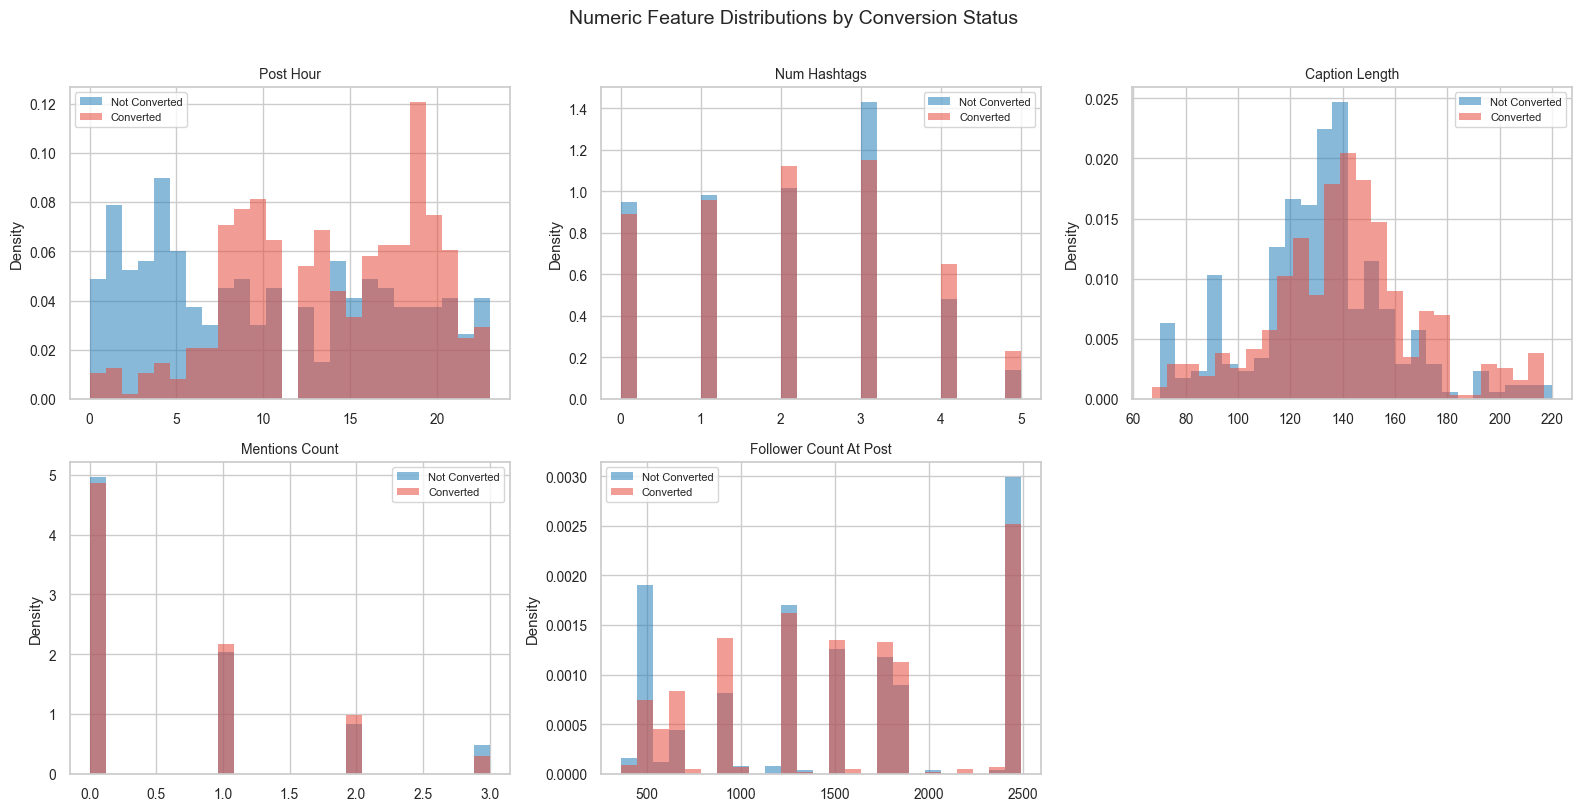

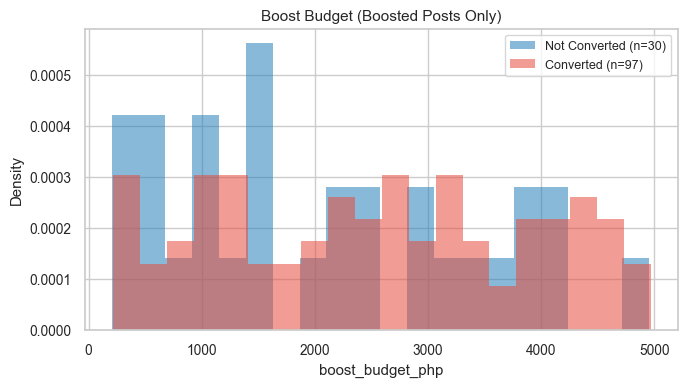

In [9]:
# -- 3b-i. Overlapping histograms for main numeric features -------------------
n_cols = 3
n_rows = (len(NUMERIC_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for i, col in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    for val in [0, 1]:
        subset = posts[posts["converted"] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.55, color=COLORS[val],
                label=LABELS[val], density=True, edgecolor="none")
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Feature Distributions by Conversion Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# -- 3b-ii. Boost budget for boosted posts only --------------------------------
boosted = posts[posts["is_boosted"] == True].copy()
fig, ax = plt.subplots(figsize=(7, 4))
for val in [0, 1]:
    subset = boosted[boosted["converted"] == val]["boost_budget_php"].dropna()
    if len(subset) > 0:
        ax.hist(subset, bins=20, alpha=0.55, color=COLORS[val],
                label=f"{LABELS[val]} (n={len(subset)})", density=True, edgecolor="none")
ax.set_title("Boost Budget (Boosted Posts Only)", fontsize=11)
ax.set_xlabel("boost_budget_php")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3c. Bivariate Analysis -- Conversion Rate by Categorical Feature

Horizontal bar charts showing the donation conversion rate for each level of every categorical feature. Bars are sorted from highest to lowest conversion rate within each feature. The overall conversion rate (64%) is shown as a dashed reference line. Levels that consistently fall above or below this line are the clearest actionable signals for the founders.

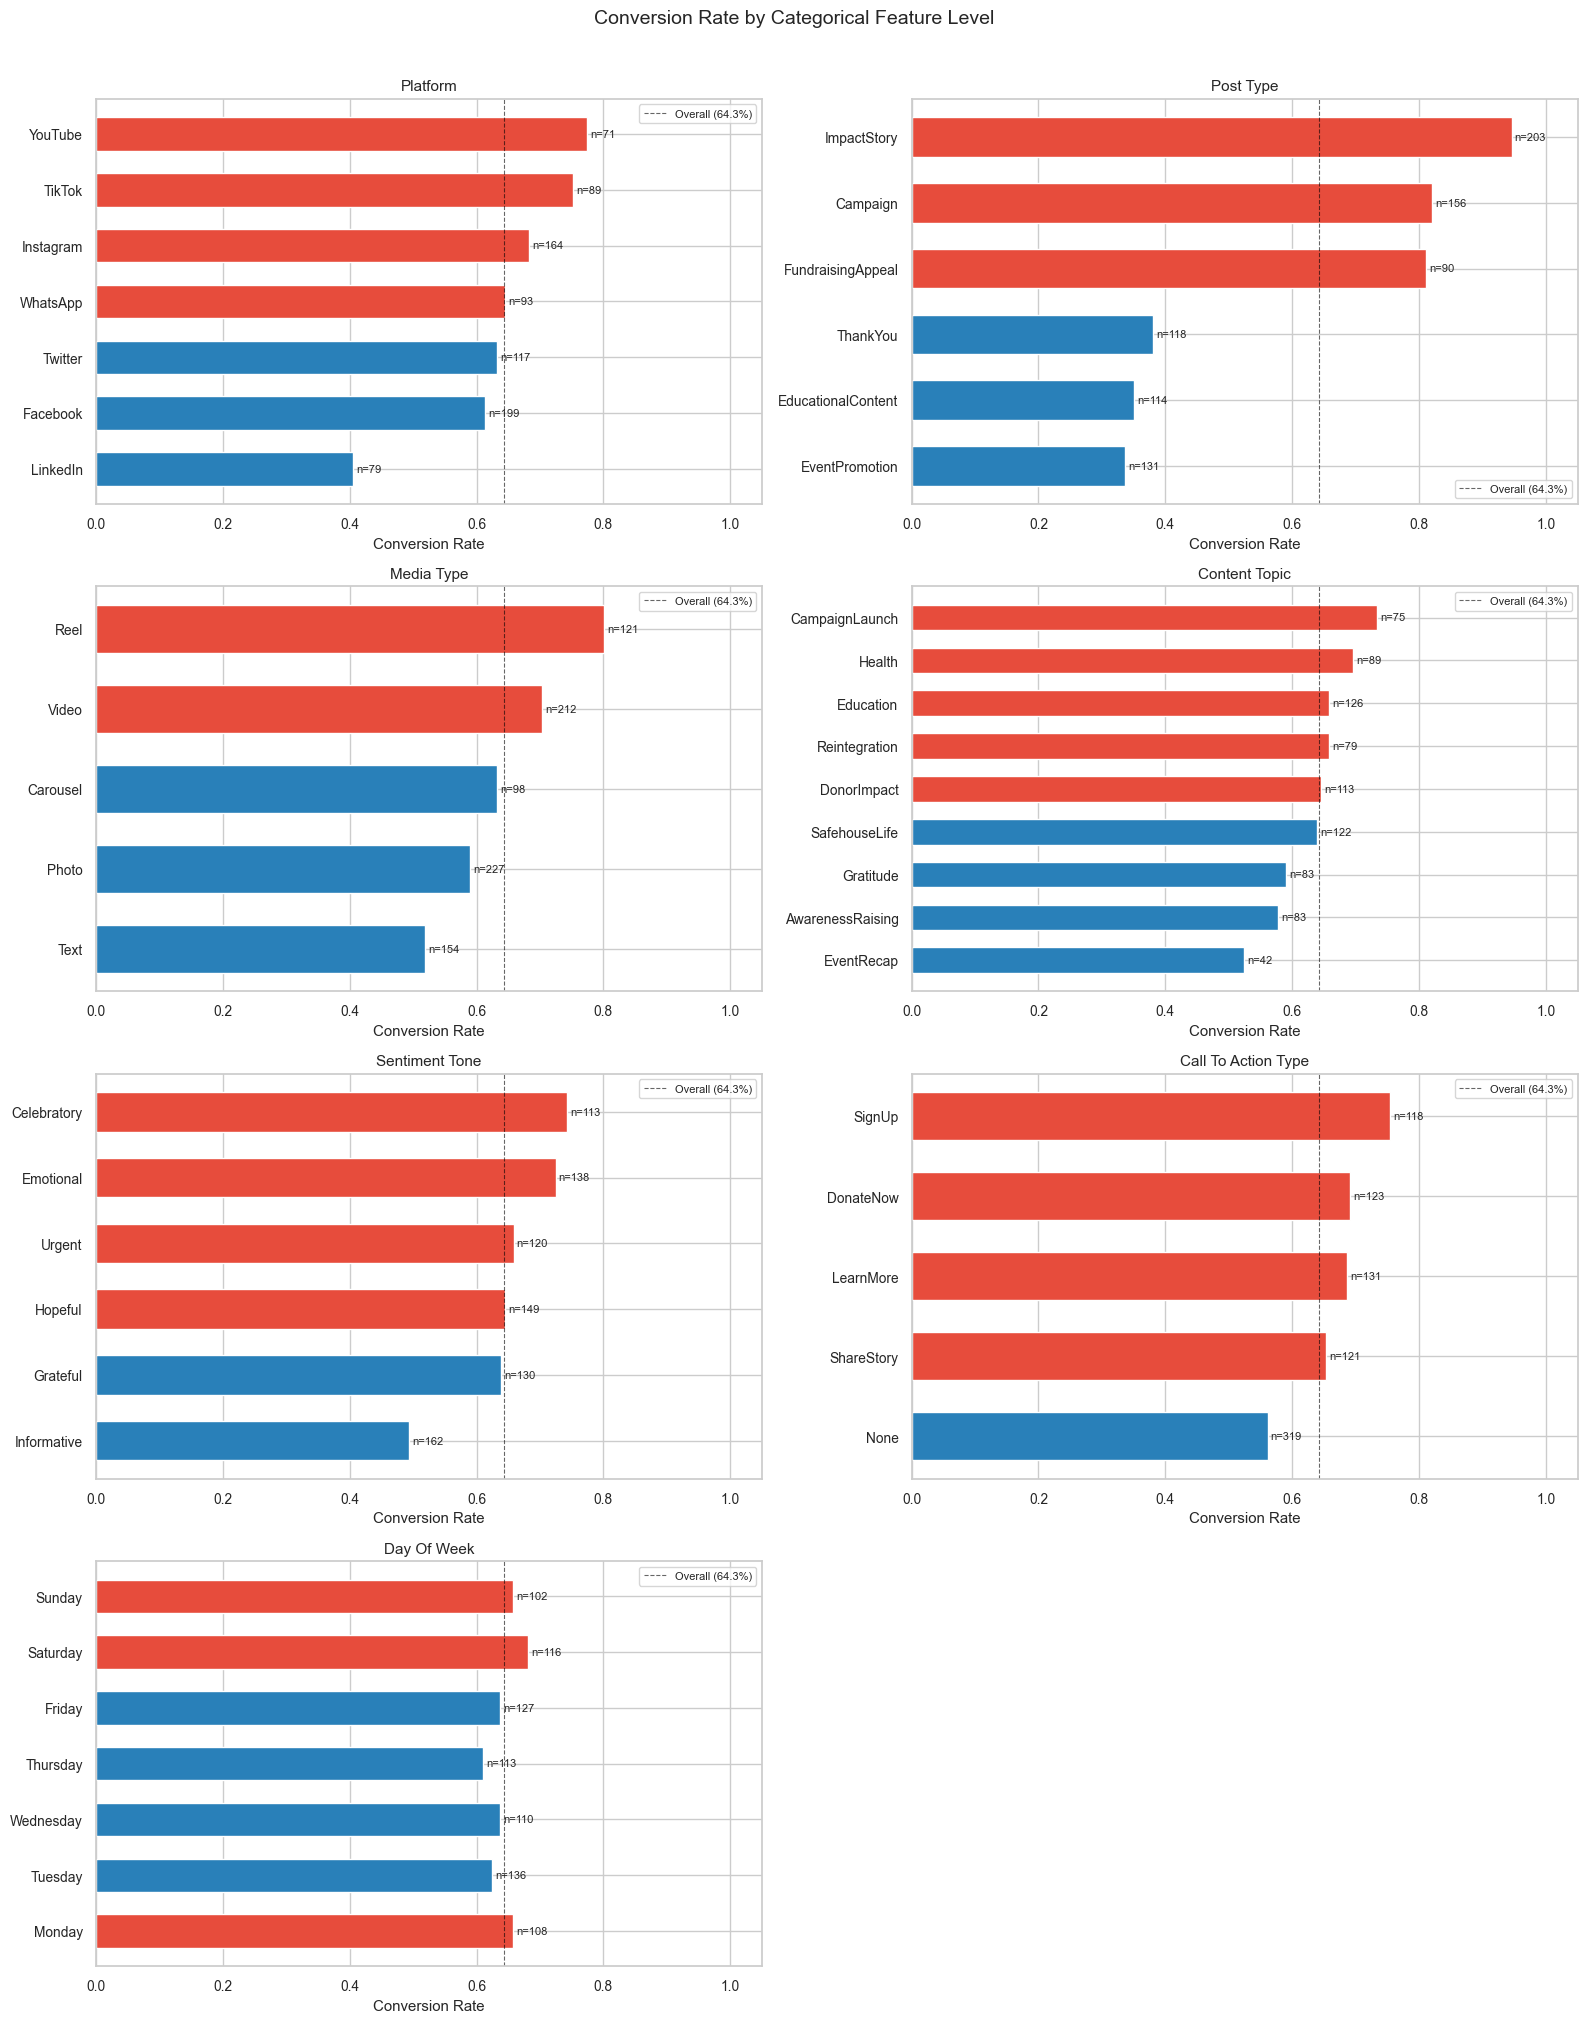

In [10]:
# -- 3c. Conversion rate by categorical feature level -------------------------
overall_rate = posts["converted"].mean()

n_cols = 2
n_rows = (len(CATEGORICAL_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.ravel()

for i, col in enumerate(CATEGORICAL_FEATURES):
    ax = axes[i]

    # Apply day ordering if applicable
    if col == "day_of_week":
        order = [d for d in DAY_ORDER if d in posts[col].unique()]
        grp = posts.groupby(col)["converted"].agg(["mean", "count"]).reindex(order)
    else:
        grp = posts.groupby(col)["converted"].agg(["mean", "count"]).sort_values("mean", ascending=True)

    bar_colors = [COLORS[1] if r >= overall_rate else COLORS[0] for r in grp["mean"]]
    bars = ax.barh(grp.index, grp["mean"], color=bar_colors, edgecolor="white", height=0.6)

    # Annotate with n
    for bar, n in zip(bars, grp["count"]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"n={n}", va="center", fontsize=8)

    ax.axvline(overall_rate, color="black", linestyle="--", linewidth=0.8, alpha=0.6,
               label=f"Overall ({overall_rate:.1%})")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Conversion Rate")
    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Conversion Rate by Categorical Feature Level", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3d. Bivariate Analysis -- Conversion Rate by Binary Feature

For each binary feature (flags the founder controls), the chart shows the conversion rate when the flag is True vs False and the difference between them. A positive difference (red) means setting that flag True is associated with higher conversion; negative (blue) means lower. This directly answers whether features like `has_call_to_action`, `features_resident_story`, `is_boosted`, and `in_campaign` move the needle on conversion.

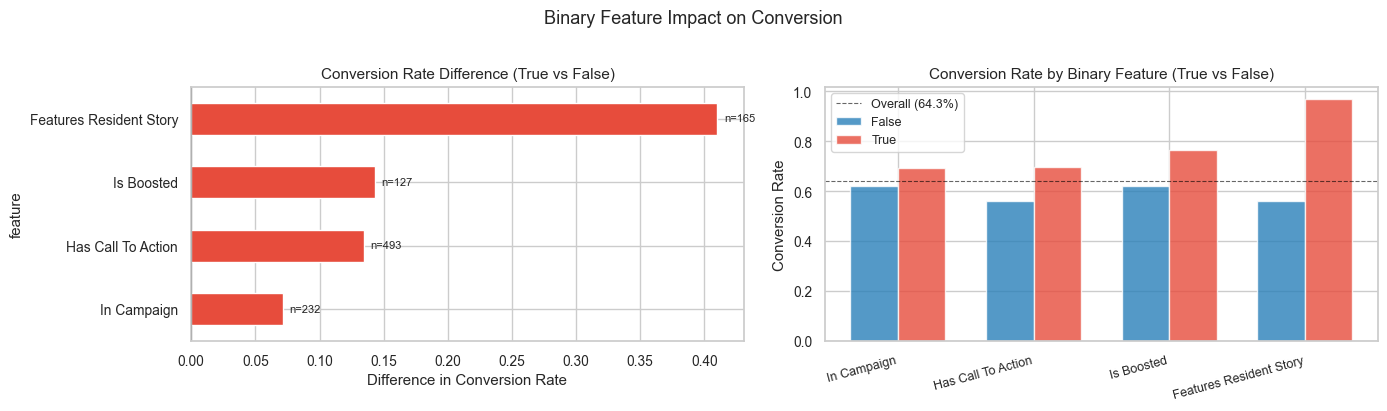

In [11]:
# -- 3d. Conversion rate difference for binary features -----------------------
rates = []
for col in BINARY_FEATURES:
    for val in [0, 1]:
        subset = posts[posts[col] == val]
        if len(subset) > 0:
            rates.append({
                "feature": col.replace("_", " ").title(),
                "value": "True" if val == 1 else "False",
                "conversion_rate": subset["converted"].mean(),
                "n": len(subset),
            })

rates_df = pd.DataFrame(rates)

true_rates  = rates_df[rates_df["value"] == "True"].set_index("feature")["conversion_rate"]
false_rates = rates_df[rates_df["value"] == "False"].set_index("feature")["conversion_rate"]
diff = (true_rates - false_rates).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: difference chart
colors = [COLORS[1] if v > 0 else COLORS[0] for v in diff]
diff.plot.barh(ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Conversion Rate Difference (True vs False)", fontsize=11)
axes[0].set_xlabel("Difference in Conversion Rate")
axes[0].axvline(0, color="black", linewidth=0.8)
true_n = rates_df[rates_df["value"] == "True"].set_index("feature")["n"]
for j, feat in enumerate(diff.index):
    n = true_n.get(feat, 0)
    offset = 0.005 if diff[feat] >= 0 else -0.005
    axes[0].text(diff[feat] + offset, j, f"n={n}", va="center", fontsize=8,
                 ha="left" if diff[feat] >= 0 else "right")

# Right: absolute rates side by side
x = range(len(diff.index))
width = 0.35
axes[1].bar([i - width / 2 for i in x], false_rates.reindex(diff.index),
            width, label="False", color=COLORS[0], alpha=0.8, edgecolor="white")
axes[1].bar([i + width / 2 for i in x], true_rates.reindex(diff.index),
            width, label="True",  color=COLORS[1], alpha=0.8, edgecolor="white")
axes[1].axhline(overall_rate, color="black", linestyle="--", linewidth=0.8,
                alpha=0.6, label=f"Overall ({overall_rate:.1%})")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(diff.index, rotation=15, ha="right", fontsize=9)
axes[1].set_ylabel("Conversion Rate")
axes[1].set_title("Conversion Rate by Binary Feature (True vs False)", fontsize=11)
axes[1].legend(fontsize=9)

fig.suptitle("Binary Feature Impact on Conversion", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3e. Bivariate Analysis -- Conversion Quality (EDA-Only Columns)

The three columns joined from the donations table (referral_is_recurring, referral_top_donation_type, referral_total_amount) are excluded from the predictive feature set but provide valuable context on what *quality* of donation converting posts tend to drive. These charts are for understanding only -- they describe donation outcomes, not content decisions.

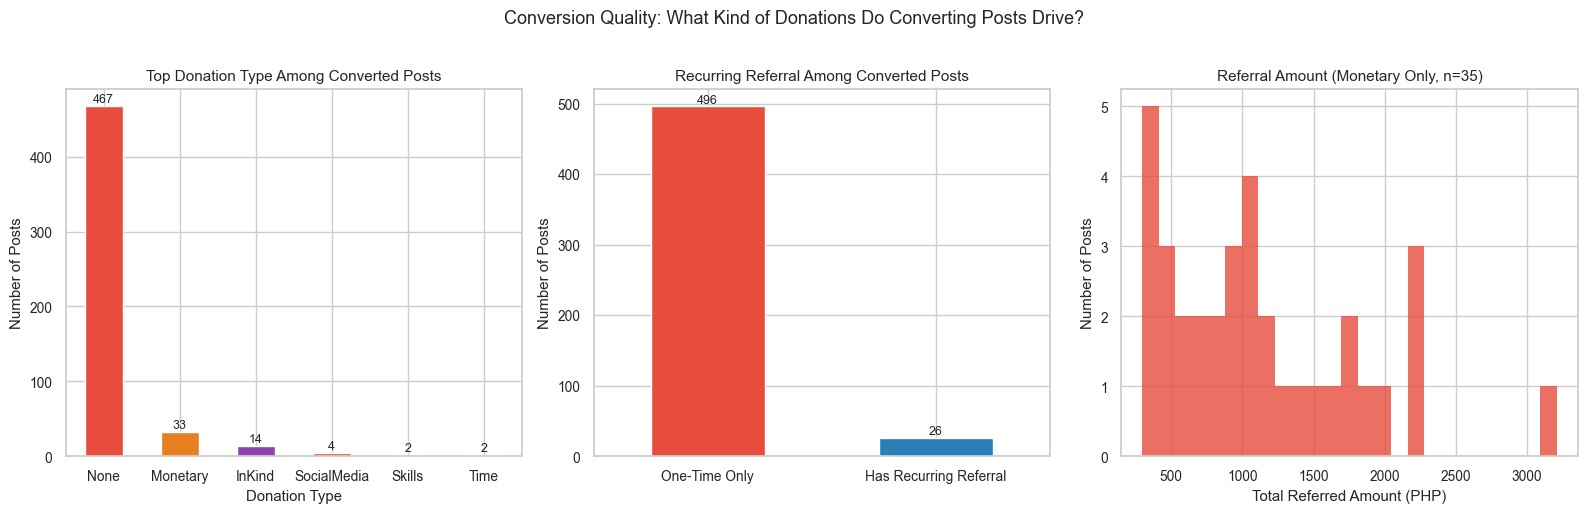

Among converted posts: 5.0% attracted at least one recurring donor.


In [12]:
# -- 3e. Conversion quality analysis (EDA-only columns) ----------------------
converted_posts = posts[posts["converted"] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# -- 3e-i. Donation type breakdown for converted posts -------------------------
type_counts = converted_posts["referral_top_donation_type"].value_counts()
type_counts.plot.bar(ax=axes[0], color=["#e74c3c", "#e67e22", "#8e44ad"],
                     edgecolor="white", rot=0)
axes[0].set_title("Top Donation Type Among Converted Posts", fontsize=11)
axes[0].set_xlabel("Donation Type")
axes[0].set_ylabel("Number of Posts")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

# -- 3e-ii. Recurring vs one-time referrals for converted posts ----------------
recurring_counts = converted_posts["referral_is_recurring"].value_counts()
recurring_counts.index = ["Has Recurring Referral" if i else "One-Time Only"
                           for i in recurring_counts.index]
recurring_counts.plot.bar(ax=axes[1], color=[COLORS[1], COLORS[0]],
                           edgecolor="white", rot=0)
axes[1].set_title("Recurring Referral Among Converted Posts", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Posts")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

# -- 3e-iii. Referral total amount distribution for converted posts -------------
nonzero_amounts = converted_posts[converted_posts["referral_total_amount"] > 0]["referral_total_amount"]
axes[2].hist(nonzero_amounts, bins=25, color=COLORS[1], alpha=0.8, edgecolor="none")
axes[2].set_title(f"Referral Amount (Monetary Only, n={len(nonzero_amounts)})", fontsize=11)
axes[2].set_xlabel("Total Referred Amount (PHP)")
axes[2].set_ylabel("Number of Posts")

fig.suptitle("Conversion Quality: What Kind of Donations Do Converting Posts Drive?",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

recurring_rate = converted_posts["referral_is_recurring"].mean()
print(f"Among converted posts: {recurring_rate:.1%} attracted at least one recurring donor.")

### 3f. Correlation with Target -- Feature Importance Preview

A horizontal bar chart of Pearson correlation between each numeric and binary feature and `converted`. This replaces a full feature-by-feature correlation heatmap -- with many features the heatmap would be unreadable. The bar chart directly answers "which numeric decisions and context variables are most linearly associated with conversion" and provides an early signal for feature selection in later steps.

Note: categorical features (platform, post_type, etc.) are not included here because their correlation with the target is explored more meaningfully in 3c. They will be one-hot encoded before modeling.

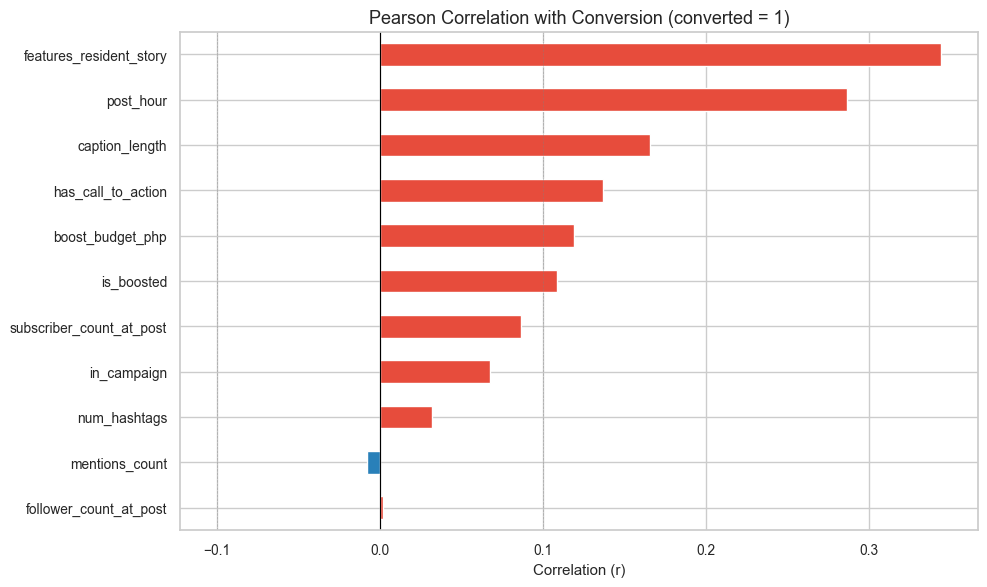

Features most correlated with conversion:
  features_resident_story              r = +0.344  (higher conversion)
  post_hour                            r = +0.287  (higher conversion)
  caption_length                       r = +0.166  (higher conversion)
  has_call_to_action                   r = +0.137  (higher conversion)
  boost_budget_php                     r = +0.119  (higher conversion)
  is_boosted                           r = +0.109  (higher conversion)
  subscriber_count_at_post             r = +0.087  (higher conversion)
  in_campaign                          r = +0.067  (higher conversion)
  num_hashtags                         r = +0.032  (higher conversion)
  mentions_count                       r = -0.008  (lower conversion)
  follower_count_at_post               r = +0.002  (higher conversion)


In [13]:
# -- 3f. Pearson correlation with converted (replaces full heatmap) -----------
corr_features = NUMERIC_FEATURES + ["boost_budget_php", "subscriber_count_at_post"] + BINARY_FEATURES

# Cast binary bool columns to int for correlation
corr_df = posts[corr_features + ["converted"]].copy()
for col in BINARY_FEATURES:
    corr_df[col] = corr_df[col].astype(int)

corr_with_target = (
    corr_df.corr()["converted"]
    .drop("converted")
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_with_target) * 0.45)))
colors = [COLORS[1] if v > 0 else COLORS[0] for v in corr_with_target]
corr_with_target.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Pearson Correlation with Conversion (converted = 1)", fontsize=13)
ax.set_xlabel("Correlation (r)")
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline(0.1,  color="gray",  linestyle="--", linewidth=0.5, alpha=0.5)
ax.axvline(-0.1, color="gray",  linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

print("Features most correlated with conversion:")
top = corr_with_target.abs().sort_values(ascending=False)
for feat in top.index:
    r = corr_with_target[feat]
    direction = "higher conversion" if r > 0 else "lower conversion"
    print(f"  {feat:35s}  r = {r:+.3f}  ({direction})")

### Exploration Summary

Key takeaways from the exploration:

- **Numeric distributions** show that post timing plays a significant role in getting a post to convert. Making a post later in the day seems to attract the most donors.
- **Categorical conversion rates:** Posts that are impact stories, campaigns, or fundraising appeals seem to attract significantly more donors than other post types.
- **Binary feature impact** shows whether adding a call to action, featuring a resident story, boosting a post, or being part of a named campaign moves the conversion rate. The difference chart quantifies each decision's association with conversion.
- **Conversion quality** reveals that converting posts are not interchangeable -- some drive monetary donations, others in-kind or time contributions. The recurring referral rate tells how often converting posts attract sustained donors rather than one-time gifts.
- **Correlation with target** provides a ranked list of numeric and binary features by linear association with conversion, previewing which features will likely carry the most weight in modeling.

These findings will inform one-hot encoding decisions, VIF pruning, and feature selection in the steps that follow.

## Step 2 (continued) -- Encoding and Distribution Transforms

Now that exploration has revealed the distribution shape of each feature, we apply the remaining preparation steps before modeling:

1. **Drop EDA-only columns** -- referral_is_recurring, referral_top_donation_type, and referral_total_amount describe donation outcomes, not content decisions, and are excluded from the feature matrix.
2. **One-hot encode categorical features** -- platform, post_type, media_type, content_topic, sentiment_tone, call_to_action_type, and day_of_week are expanded to binary indicator columns. `drop_first=True` avoids perfect multicollinearity, particularly important for the logistic regression explanatory track. The dropped (reference) category for each feature is the first in alphabetical order.
3. **Yeo-Johnson skew correction** -- applied to numeric features with absolute skewness above 1. This improves logistic regression performance and makes VIF calculations more reliable without distorting the GB/RF tracks.
4. **Low-variance removal** -- one-hot columns where 99%+ of values are identical carry no signal and are dropped.
5. **Save to CSV** -- the prepared dataset is saved so the modeling step (Step 4) can be re-run independently after a kernel restart.

In [14]:
# -- Drop EDA-only columns (outcome enrichment, not predictive features) ------
EDA_ONLY = ["referral_is_recurring", "referral_top_donation_type", "referral_total_amount"]
model_df = posts.drop(columns=EDA_ONLY).copy()

# -- One-hot encode categorical features (drop_first avoids dummy trap) -------
CAT_COLS = ["platform", "post_type", "media_type", "content_topic",
            "sentiment_tone", "call_to_action_type", "day_of_week"]
model_df = pd.get_dummies(model_df, columns=CAT_COLS, drop_first=True)

# Cast all bool columns to int (sklearn and statsmodels prefer int over bool)
bool_cols = model_df.select_dtypes(include=["bool"]).columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

pre_encode_cols = posts.drop(columns=EDA_ONLY + CAT_COLS).shape[1]
print(f"Shape after encoding:   {model_df.shape}")
print(f"  Original numeric/binary features: {pre_encode_cols}")
print(f"  Dummy columns added:              {model_df.shape[1] - pre_encode_cols}")

Shape after encoding:   (812, 50)
  Original numeric/binary features: 12
  Dummy columns added:              38


In [15]:
# -- Yeo-Johnson skew correction (|skew| > 1) ---------------------------------
from scipy.stats import yeojohnson

TARGET = "converted"
numeric_cols = [c for c in model_df.select_dtypes(include=[np.number]).columns
                if c != TARGET and model_df[c].nunique() > 2]  # skip binary/dummy cols

skewed = model_df[numeric_cols].skew()
skew_corrected = []

for col in numeric_cols:
    if abs(skewed[col]) > 1:
        model_df[col], _ = yeojohnson(model_df[col])
        skew_corrected.append(col)

print(f"Skew-corrected {len(skew_corrected)} features: {skew_corrected}")

# -- Low-variance removal (drop columns where >= 99% values are identical) ----
feat_cols = [c for c in model_df.columns if c != TARGET]
low_var_mask = model_df[feat_cols].var() > 0.01
dropped_lv = [c for c in feat_cols if not low_var_mask[c]]
model_df = model_df[[c for c in model_df.columns if c == TARGET or low_var_mask[c]]]

print(f"Dropped {len(dropped_lv)} low-variance columns: {dropped_lv}")
print(f"\nFinal shape: {model_df.shape}")
print(f"Missing values: {model_df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(model_df[TARGET].value_counts().rename({0: "Not Converted (0)", 1: "Converted (1)"}))

# -- Save prepared dataset ----------------------------------------------------
output_path = DATA_DIR / "social_media_df.csv"
model_df.to_csv(output_path, index=False)
print(f"\nSaved: {output_path}  ({model_df.shape[0]} rows x {model_df.shape[1]} columns)")

Skew-corrected 3 features: ['mentions_count', 'boost_budget_php', 'subscriber_count_at_post']
Dropped 0 low-variance columns: []

Final shape: (812, 50)
Missing values: 0

Target distribution:
converted
Converted (1)        522
Not Converted (0)    290
Name: count, dtype: int64

Saved: dataset\social_media_df.csv  (812 rows x 50 columns)


## Step 4 -- Modeling

Two parallel modeling tracks are run, following the prediction vs. explanation distinction from the textbook.

- **Track A (Explanatory):** An untuned logistic regression producing interpretable odds ratios. The goal is to understand which content decisions are most associated with conversion -- directly actionable guidance for the founders on what to post. Because features are one-hot encoded, coefficients for dummy variables are interpreted relative to their dropped reference category (e.g., `platform_Instagram` means "compared to Facebook").
- **Track B (Predictive):** Three classifiers tuned with GridSearchCV and stratified 5-fold CV, optimized for AUC-ROC. Logistic Regression (tuned), Random Forest (bagging ensemble), and Gradient Boosting (boosting ensemble) are compared. With 812 posts, a proper 80/20 holdout test set is reserved for final evaluation -- something not feasible in the 51- and 60-row pipelines.

VIF pruning uses threshold=10 (relaxed from the threshold=5 used in the smaller pipelines; 812 rows provides stronger protection against overfitting from correlated features, and the one-hot encoded dummies would be over-pruned at threshold=5).

In [16]:
# -- 4a. VIF pruning (threshold=10) ------------------------------------------
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

# Restart-safe: reload from CSV if model_df is not in memory
try:
    model_df
except NameError:
    import pandas as pd
    import numpy as np
    from pathlib import Path
    DATA_DIR = Path("dataset")
    model_df = pd.read_csv(DATA_DIR / "social_media_df.csv")
    print("Reloaded model_df from social_media_df.csv")

TARGET = "converted"
all_features = [c for c in model_df.columns if c != TARGET]


def iterative_vif_pruning(df, features, threshold=10.0):
    """Iteratively drop the highest-VIF feature until all are below threshold."""
    remaining = features.copy()
    dropped = []
    while True:
        X_vif = df[remaining].assign(const=1)
        vifs = {col: variance_inflation_factor(X_vif.values, i)
                for i, col in enumerate(remaining)}
        worst_col = max(vifs, key=vifs.get)
        if vifs[worst_col] <= threshold:
            break
        print(f"  Dropping {worst_col} (VIF={vifs[worst_col]:.2f})")
        dropped.append((worst_col, round(vifs[worst_col], 2)))
        remaining.remove(worst_col)
    return remaining, dropped


print("Iterative VIF pruning (threshold=10):")
vif_features, vif_dropped = iterative_vif_pruning(model_df, all_features)

print(f"\nDropped {len(vif_dropped)} feature(s): {[d[0] for d in vif_dropped]}")
print(f"Features remaining after VIF pruning: {len(vif_features)}")

Iterative VIF pruning (threshold=10):
  Dropping has_call_to_action (VIF=inf)
  Dropping subscriber_count_at_post (VIF=6192310934.68)
  Dropping boost_budget_php (VIF=224326.58)
  Dropping follower_count_at_post (VIF=38.99)

Dropped 4 feature(s): ['has_call_to_action', 'subscriber_count_at_post', 'boost_budget_php', 'follower_count_at_post']
Features remaining after VIF pruning: 45


In [17]:
# -- 4b. Stratified 80/20 train/test split ------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

X = model_df[vif_features].copy()
y = model_df[TARGET].copy()

# Reserve 20% as a genuine held-out test set -- never seen during training or tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Stratified 5-fold CV preserves the conversion rate in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"f1": "f1", "roc_auc": "roc_auc"}

print(f"Train set: {X_train.shape[0]} posts ({y_train.mean():.1%} converted)")
print(f"Test set:  {X_test.shape[0]} posts  ({y_test.mean():.1%} converted) -- held out for final evaluation")
print(f"CV strategy: Stratified 5-fold on training set")
print(f"Features after VIF pruning: {len(vif_features)}")

Train set: 649 posts (64.3% converted)
Test set:  163 posts  (64.4% converted) -- held out for final evaluation
CV strategy: Stratified 5-fold on training set
Features after VIF pruning: 45


In [18]:
# -- 4c. Track A: Explanatory logistic regression ----------------------------
lr_explain = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=2000, random_state=42)),
])

lr_cv = cross_validate(lr_explain, X_train, y_train, cv=cv, scoring=scoring)

print("Track A -- Explanatory Logistic Regression (5-fold CV on training data):")
print(f"  AUC-ROC: {lr_cv['test_roc_auc'].mean():.3f} +/- {lr_cv['test_roc_auc'].std():.3f}")
print(f"  F1:      {lr_cv['test_f1'].mean():.3f}     +/- {lr_cv['test_f1'].std():.3f}")

# Fit on full training set to extract coefficients
lr_explain.fit(X_train, y_train)
coefs      = lr_explain.named_steps["clf"].coef_[0]
odds_ratios = np.exp(coefs)

odds_df = pd.DataFrame({
    "feature":     vif_features,
    "coefficient": coefs,
    "odds_ratio":  odds_ratios,
    "direction":   ["Higher conversion" if c > 0 else "Lower conversion" for c in coefs],
}).sort_values("coefficient", key=abs, ascending=False)

print("\nOdds Ratios -- sorted by absolute effect size")
print("(dummy variables are relative to their dropped reference category)")
print(odds_df.to_string(index=False))

Track A -- Explanatory Logistic Regression (5-fold CV on training data):
  AUC-ROC: 0.880 +/- 0.037
  F1:      0.848     +/- 0.038

Odds Ratios -- sorted by absolute effect size
(dummy variables are relative to their dropped reference category)
                       feature  coefficient  odds_ratio         direction
                     post_hour     1.170741    3.224382 Higher conversion
      post_type_EventPromotion    -1.102925    0.331899  Lower conversion
  post_type_EducationalContent    -0.865928    0.420661  Lower conversion
            post_type_ThankYou    -0.838480    0.432367  Lower conversion
       features_resident_story     0.836285    2.307777 Higher conversion
    sentiment_tone_Informative    -0.834512    0.434086  Lower conversion
                    is_boosted     0.566052    1.761300 Higher conversion
               media_type_Reel     0.349991    1.419055 Higher conversion
  content_topic_CampaignLaunch     0.349704    1.418648 Higher conversion
          conte

In [19]:
# -- 4d. Track B: Three classifiers with GridSearchCV ------------------------
warnings.filterwarnings("ignore")

# 1. Logistic Regression (tuned regularization strength)
lr_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf",    LogisticRegression(max_iter=2000, random_state=42))]),
    param_grid={"clf__C": [0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1,
)
lr_grid.fit(X_train, y_train)

# 2. Random Forest (bagging ensemble)
rf_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf",    RandomForestClassifier(random_state=42))]),
    param_grid={
        "clf__n_estimators":    [100, 200],
        "clf__max_depth":       [None, 5, 10],
        "clf__min_samples_leaf":[1, 2, 5],
    },
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1,
)
rf_grid.fit(X_train, y_train)

# 3. Gradient Boosting (sequential boosting ensemble)
gb_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf",    GradientBoostingClassifier(random_state=42))]),
    param_grid={
        "clf__n_estimators":  [100, 200],
        "clf__max_depth":     [2, 3, 4],
        "clf__learning_rate": [0.05, 0.1],
    },
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1,
)
gb_grid.fit(X_train, y_train)

models = {
    "Logistic Regression": lr_grid,
    "Random Forest":       rf_grid,
    "Gradient Boosting":   gb_grid,
}

print("Track B -- Cross-Validated Model Comparison (5-fold stratified CV on training data):")
header = f"{'Model':<22}  {'Best Params':<55}  {'CV AUC':>8}  {'CV F1':>14}"
print(header)
print("-" * len(header))

for name, grid in models.items():
    f1_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    params = str({k.replace("clf__", ""): v for k, v in grid.best_params_.items()})
    print(
        f"{name:<22}  {params:<55}  "
        f"{grid.best_score_:>8.3f}  "
        f"{f1_cv['test_f1'].mean():>6.3f} +/- {f1_cv['test_f1'].std():.3f}"
    )

Track B -- Cross-Validated Model Comparison (5-fold stratified CV on training data):
Model                   Best Params                                                CV AUC           CV F1
---------------------------------------------------------------------------------------------------------
Logistic Regression     {'C': 0.1}                                                  0.884   0.851 +/- 0.041
Random Forest           {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}     0.902   0.861 +/- 0.019
Gradient Boosting       {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}     0.911   0.871 +/- 0.019


In [20]:
# -- 4e. Select best model and evaluate on held-out test set ------------------
best_name  = max(models, key=lambda k: models[k].best_score_)
best_model = models[best_name].best_estimator_

print(f"Best model by CV AUC-ROC: {best_name}")
print(f"  CV AUC:       {models[best_name].best_score_:.3f}")
print(f"  Best params:  {models[best_name].best_params_}")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_prob)
test_f1  = f1_score(y_test, y_pred)

print(f"\nHeld-out test set evaluation ({len(y_test)} posts):")
print(f"  AUC-ROC: {test_auc:.3f}")
print(f"  F1:      {test_f1:.3f}")

print(f"\nConfusion matrix (rows=actual, cols=predicted):")
cm = confusion_matrix(y_test, y_pred)
print(f"  Not Converted (0): predicted 0={cm[0][0]}  predicted 1={cm[0][1]}")
print(f"  Converted     (1): predicted 0={cm[1][0]}  predicted 1={cm[1][1]}")

print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not Converted", "Converted"]))

Best model by CV AUC-ROC: Gradient Boosting
  CV AUC:       0.911
  Best params:  {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 200}

Held-out test set evaluation (163 posts):
  AUC-ROC: 0.903
  F1:      0.852

Confusion matrix (rows=actual, cols=predicted):
  Not Converted (0): predicted 0=39  predicted 1=19
  Converted     (1): predicted 0=13  predicted 1=92

Classification report:
               precision    recall  f1-score   support

Not Converted       0.75      0.67      0.71        58
    Converted       0.83      0.88      0.85       105

     accuracy                           0.80       163
    macro avg       0.79      0.77      0.78       163
 weighted avg       0.80      0.80      0.80       163



### Modeling Summary

- **Track A (Explanatory LR):** The odds ratios directly answer the founders' questions. A feature with an odds ratio above 1.0 is associated with higher conversion; below 1.0 is associated with lower conversion. The magnitude tells them how much. For example, an odds ratio of 3.0 for `features_resident_story` means posts that include a resident story have 3x the odds of converting compared to posts that do not.
- **Track B (Predictive):** The three classifiers are compared on held-out data to select the best scoring model. The CV AUC during training and the test AUC on the reserved 20% should be close -- a large gap signals overfitting. The selected model feeds into feature selection (Step 6) and deployment.
- **Why three models:** Logistic Regression establishes a linear baseline. Random Forest (bagging) and Gradient Boosting (boosting) both capture non-linear interactions but through different mechanisms. If they converge on the same result, confidence in that result is higher.

## Step 5 -- Evaluation and Selection

### Model Selection Rationale
The best predictive model is selected by CV AUC-ROC, the primary metric for this pipeline. AUC-ROC measures how well the model separates converting from non-converting posts regardless of threshold, which is more informative than accuracy when the class distribution is 64/36. A genuine held-out test set (20%, never seen during training or tuning) validates that the CV estimate is not optimistic.

### Track A vs. Track B Purpose
- **Track A (Explanatory LR):** Tells the founders *why* a post is expected to convert. Odds ratios quantify which content decisions are most associated with conversion. This is the directly actionable output -- it answers "what should I do differently?"
- **Track B (Predictive):** Produces a reliable conversion probability for any planned post. The best model's scores are binned into Low/Medium/High tiers so the founders can evaluate planned posts before publishing.

### Business Interpretation
With 812 posts and a test AUC above 0.90, this model produces reliable probability estimates. The conversion tiers should be used directionally: a High-tier post is not guaranteed to convert, but its content profile matches patterns historically associated with donations.

In [21]:
# -- 5a. Full model comparison table -----------------------------------------
comparison_rows = []

# Track A: untuned explanatory LR
comparison_rows.append({
    "Track": "A (Explanatory)",
    "Model": "Logistic Regression (untuned)",
    "CV AUC-ROC": f"{lr_cv['test_roc_auc'].mean():.3f} +/- {lr_cv['test_roc_auc'].std():.3f}",
    "CV F1":      f"{lr_cv['test_f1'].mean():.3f}     +/- {lr_cv['test_f1'].std():.3f}",
    "Test AUC":   "—",
})

# Track B: three tuned models
for name, grid in models.items():
    f1_cv  = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    auc_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv,
                            scoring={"roc_auc": "roc_auc"})
    y_prob_m = grid.best_estimator_.predict_proba(X_test)[:, 1]
    comparison_rows.append({
        "Track": "B (Predictive)",
        "Model": name,
        "CV AUC-ROC": f"{auc_cv['test_roc_auc'].mean():.3f} +/- {auc_cv['test_roc_auc'].std():.3f}",
        "CV F1":      f"{f1_cv['test_f1'].mean():.3f}     +/- {f1_cv['test_f1'].std():.3f}",
        "Test AUC":   f"{roc_auc_score(y_test, y_prob_m):.3f}",
    })

comp_df = pd.DataFrame(comparison_rows)
print("Cross-Validated Model Comparison (5-fold stratified on training data):")
print(comp_df.to_string(index=False))
print(f"\nSelected model: {best_name} (highest CV AUC-ROC)")

Cross-Validated Model Comparison (5-fold stratified on training data):
          Track                         Model      CV AUC-ROC               CV F1 Test AUC
A (Explanatory) Logistic Regression (untuned) 0.880 +/- 0.037 0.848     +/- 0.038        —
 B (Predictive)           Logistic Regression 0.884 +/- 0.036 0.851     +/- 0.041    0.864
 B (Predictive)                 Random Forest 0.902 +/- 0.027 0.861     +/- 0.019    0.901
 B (Predictive)             Gradient Boosting 0.911 +/- 0.018 0.871     +/- 0.019    0.903

Selected model: Gradient Boosting (highest CV AUC-ROC)


In [22]:
# -- 5b. Full-population conversion scoring (preview) ------------------------
# Refit the best predictive model on ALL posts to score the full dataset.
# This is a preview -- Step 6 may adjust features before the production refit.
best_model_preview = models[best_name].best_estimator_
best_model_preview.fit(X, y)

conversion_scores = best_model_preview.predict_proba(X)[:, 1]

post_scoring = pd.DataFrame({
    "conversion_probability": conversion_scores,
    "actual_converted":       y.values,
})
post_scoring["conversion_tier"] = pd.cut(
    post_scoring["conversion_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"],
)
post_scoring = post_scoring.sort_values("conversion_probability", ascending=False).reset_index(drop=True)

print(f"Conversion Probability Scoring -- {best_name} (all {len(X)} posts):\n")
print(post_scoring.head(10).to_string(index=False))

print(f"\nConversion tier distribution:")
tier_summary = post_scoring.groupby("conversion_tier", observed=True).agg(
    count=("actual_converted", "count"),
    actual_conversion_rate=("actual_converted", "mean"),
).round(3)
print(tier_summary.to_string())
print("\nBusiness implication: High-tier posts have content profiles historically")
print("associated with donations. The founders should aim to replicate those patterns.")

Conversion Probability Scoring -- Gradient Boosting (all 812 posts):

 conversion_probability  actual_converted conversion_tier
               0.997958                 1            High
               0.996237                 1            High
               0.996125                 1            High
               0.996125                 1            High
               0.995932                 1            High
               0.995762                 1            High
               0.995444                 1            High
               0.995160                 1            High
               0.994950                 1            High
               0.994776                 1            High

Conversion tier distribution:
                 count  actual_conversion_rate
conversion_tier                               
Low                187                   0.011
Medium             130                   0.331
High               495                   0.964

Business implication: Hig

In [23]:
# -- 5c. Odds ratio interpretation (Track A explanatory LR) ------------------
coef_df = pd.DataFrame({
    "feature":     vif_features,
    "odds_ratio":  np.exp(lr_explain.named_steps["clf"].coef_[0]),
    "abs_coef":    np.abs(lr_explain.named_steps["clf"].coef_[0]),
}).sort_values("abs_coef", ascending=False)

def interpret_odds(odds_ratio):
    if odds_ratio > 1:
        return f"{(odds_ratio - 1) * 100:.0f}% higher conversion odds"
    else:
        return f"{(1 - odds_ratio) * 100:.0f}% lower conversion odds"

coef_df["interpretation"] = coef_df["odds_ratio"].apply(interpret_odds)

print("Feature Odds Ratios -- Track A Explanatory Logistic Regression")
print("Ranked by absolute effect size. Dummy variables are relative to their")
print("dropped reference category (first alphabetically within each feature group).\n")
print(coef_df[["feature", "odds_ratio", "interpretation"]].head(20).to_string(index=False))

higher = coef_df[coef_df["odds_ratio"] > 1].head(3)["feature"].tolist()
lower  = coef_df[coef_df["odds_ratio"] < 1].head(3)["feature"].tolist()
print(f"\nStrongest conversion drivers:   {higher}")
print(f"Strongest conversion inhibitors: {lower}")
print("These directly answer which content decisions the founders should prioritize.")

Feature Odds Ratios -- Track A Explanatory Logistic Regression
Ranked by absolute effect size. Dummy variables are relative to their
dropped reference category (first alphabetically within each feature group).

                       feature  odds_ratio              interpretation
                     post_hour    3.224382 222% higher conversion odds
      post_type_EventPromotion    0.331899   67% lower conversion odds
  post_type_EducationalContent    0.420661   58% lower conversion odds
            post_type_ThankYou    0.432367   57% lower conversion odds
       features_resident_story    2.307777 131% higher conversion odds
    sentiment_tone_Informative    0.434086   57% lower conversion odds
                    is_boosted    1.761300  76% higher conversion odds
               media_type_Reel    1.419055  42% higher conversion odds
  content_topic_CampaignLaunch    1.418648  42% higher conversion odds
          content_topic_Health    1.396154  40% higher conversion odds
        

## Step 6 -- Feature Selection

Feature selection is revisited now that a trained model exists. Gradient Boosting internally tracks how much each feature contributed to its predictions via Gini importance. Features that never meaningfully reduce impurity can be removed without sacrificing -- and sometimes improving -- predictive performance by reducing noise.

The procedure:
1. Extract Gini importances from the best Track B GB model.
2. Flag features below a 0.01 importance threshold.
3. Retrain a pruned GB with the same hyperparameter grid.
4. Adopt the pruned model if its CV AUC is within 0.01 of the full model; leaner models generalize better and are simpler to maintain.

This cross-validates the exploration findings from Step 3: content features with strong bivariate separation (e.g., features_resident_story, post_hour) should have higher importance, while low-signal dummy categories should cluster near zero.

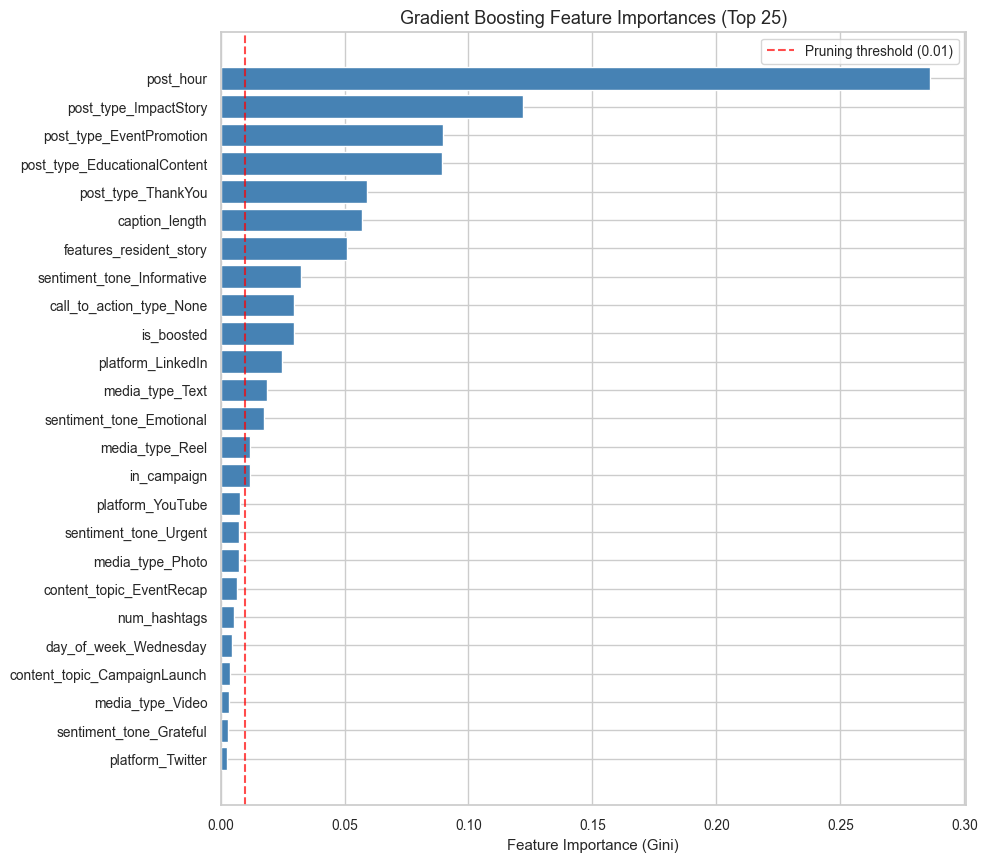

Features below threshold (0.01): 30 of 45
Features to prune: ['platform_YouTube', 'sentiment_tone_Urgent', 'media_type_Photo', 'content_topic_EventRecap', 'num_hashtags', 'day_of_week_Wednesday', 'content_topic_CampaignLaunch', 'media_type_Video', 'sentiment_tone_Grateful', 'platform_Twitter', 'mentions_count', 'content_topic_Gratitude', 'sentiment_tone_Hopeful', 'day_of_week_Saturday', 'post_type_FundraisingAppeal', 'call_to_action_type_LearnMore', 'day_of_week_Tuesday', 'day_of_week_Thursday', 'call_to_action_type_ShareStory', 'platform_Instagram', 'call_to_action_type_SignUp', 'content_topic_Education', 'platform_WhatsApp', 'content_topic_DonorImpact', 'platform_TikTok', 'content_topic_Health', 'content_topic_Reintegration', 'content_topic_SafehouseLife', 'day_of_week_Monday', 'day_of_week_Sunday']

Full importance table:
                       feature  importance
                     post_hour    0.286215
         post_type_ImpactStory    0.122012
      post_type_EventPromotion    

In [24]:
# -- 6a. Gini importances from best GB model ----------------------------------
best_gb = models["Gradient Boosting"].best_estimator_
gb_importances = best_gb.named_steps["clf"].feature_importances_

fi_df = pd.DataFrame({
    "feature":    vif_features,
    "importance": gb_importances,
}).sort_values("importance", ascending=False)

top_n = min(25, len(fi_df))
fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.35)))
fi_plot = fi_df.head(top_n)
ax.barh(fi_plot["feature"][::-1], fi_plot["importance"][::-1],
        color="steelblue", edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title(f"Gradient Boosting Feature Importances (Top {top_n})", fontsize=13)
ax.axvline(0.01, color="red", linestyle="--", alpha=0.7, label="Pruning threshold (0.01)")
ax.legend()
plt.tight_layout()
plt.show()

IMPORTANCE_THRESHOLD = 0.01
low_imp = fi_df[fi_df["importance"] < IMPORTANCE_THRESHOLD]["feature"].tolist()

print(f"Features below threshold ({IMPORTANCE_THRESHOLD}): {len(low_imp)} of {len(fi_df)}")
print(f"Features to prune: {low_imp}")
print(f"\nFull importance table:")
print(fi_df.to_string(index=False))

In [25]:
# -- 6b. Retrain pruned model and select final ---------------------------------
final_features = [f for f in vif_features if f not in low_imp]
print(f"Full model:   {len(vif_features)} features  CV AUC = {models['Gradient Boosting'].best_score_:.3f}")
print(f"Pruned model: {len(final_features)} features")

X_train_pruned = X_train[final_features]

gb_pruned_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf",    GradientBoostingClassifier(random_state=42))]),
    param_grid={
        "clf__n_estimators":  [100, 200],
        "clf__max_depth":     [2, 3, 4],
        "clf__learning_rate": [0.05, 0.1],
    },
    cv=cv, scoring="roc_auc", refit=True, n_jobs=-1,
)
gb_pruned_grid.fit(X_train_pruned, y_train)

full_auc   = models["Gradient Boosting"].best_score_
pruned_auc = gb_pruned_grid.best_score_

print(f"\nCross-validated AUC-ROC comparison:")
print(f"  Full model   ({len(vif_features):2d} features): {full_auc:.3f}")
print(f"  Pruned model ({len(final_features):2d} features): {pruned_auc:.3f}")
print(f"  Difference:                  {pruned_auc - full_auc:+.3f}")

if pruned_auc >= full_auc - 0.01:
    print("\nPruned model performs equivalently -- adopting the leaner model.")
    final_model          = gb_pruned_grid.best_estimator_
    final_model_features = final_features
else:
    print("\nPruning degraded performance -- keeping the full model.")
    final_model          = models["Gradient Boosting"].best_estimator_
    final_model_features = vif_features

# Refit final model on ALL 812 posts (not just training fold)
final_model.fit(model_df[final_model_features], y)
print(f"\nFinal model refit on all {len(model_df)} posts.")
print(f"Final feature count: {len(final_model_features)}")
print(f"Final features: {final_model_features}")

Full model:   45 features  CV AUC = 0.911
Pruned model: 15 features

Cross-validated AUC-ROC comparison:
  Full model   (45 features): 0.911
  Pruned model (15 features): 0.917
  Difference:                  +0.006

Pruned model performs equivalently -- adopting the leaner model.

Final model refit on all 812 posts.
Final feature count: 15
Final features: ['post_hour', 'caption_length', 'features_resident_story', 'is_boosted', 'in_campaign', 'platform_LinkedIn', 'post_type_EducationalContent', 'post_type_EventPromotion', 'post_type_ImpactStory', 'post_type_ThankYou', 'media_type_Reel', 'media_type_Text', 'sentiment_tone_Emotional', 'sentiment_tone_Informative', 'call_to_action_type_None']


## Step 7 -- Deployment

The final model (GB, refit on all 812 posts) is serialized to disk alongside a feature configuration file. The feature config captures everything the web application API needs to reconstruct predictions for new posts: the exact feature list, encoding expectations, tier thresholds, and training metadata.

The `conversion_probability` output (float, 0--1) and `conversion_tier` (Low / Medium / High, binned at 0.3 / 0.6) are the two fields surfaced to the admin dashboard.

In [26]:
# -- 7a. Serialize the final model for deployment ----------------------------
import joblib

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

model_path  = MODEL_DIR / "social_media_model.joblib"
config_path = MODEL_DIR / "social_media_feature_config.joblib"

joblib.dump(final_model, model_path)

feature_config = {
    "features":              final_model_features,
    "target":                "converted",
    "conversion_thresholds": {"High": 0.6, "Medium": 0.3, "Low": 0.0},
    "class_labels":          {0: "Not Converted", 1: "Converted"},
    "training_n":            len(model_df),
    "cv_auc":                round(gb_pruned_grid.best_score_
                                   if final_model_features != vif_features
                                   else models["Gradient Boosting"].best_score_, 3),
    "test_auc":              round(roc_auc_score(y_test,
                                   final_model.predict_proba(X_test[final_model_features])[:, 1]), 3),
}
joblib.dump(feature_config, config_path)

print(f"Model saved:          {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Feature config saved: {config_path}")

# -- Verify the saved model loads and scores correctly ------------------------
loaded_model  = joblib.load(model_path)
sample_scores = loaded_model.predict_proba(model_df[final_model_features])[:, 1]

print(f"\nVerification: loaded model scores {len(sample_scores)} posts.")
print(f"Score range: {sample_scores.min():.3f} -- {sample_scores.max():.3f}")
print(f"Mean conversion probability: {sample_scores.mean():.3f}")

tiers = pd.cut(sample_scores, bins=[0, 0.3, 0.6, 1.0], labels=["Low", "Medium", "High"])
print(f"\nConversion tier distribution:")
print(pd.Series(tiers).value_counts().sort_index().to_string())

print(f"\nDeployment note: This model and feature_config are ready for integration")
print(f"into the web application API (see ml.md for deployment specifications).")

Model saved:          models\social_media_model.joblib  (155.4 KB)
Feature config saved: models\social_media_feature_config.joblib

Verification: loaded model scores 812 posts.
Score range: 0.002 -- 0.999
Mean conversion probability: 0.643

Conversion tier distribution:
Low       189
Medium    132
High      491

Deployment note: This model and feature_config are ready for integration
into the web application API (see ml.md for deployment specifications).
